<a href="https://colab.research.google.com/github/siddharthkalyavit2025/crownd-density-estimator/blob/main/Crowd_Density_Estimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
  !pip install opencv-python scipy tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import glob
import torch
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.ndimage import gaussian_filter

import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import models

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/ShanghaiTech/part_B"

TRAIN_IMG_PATH = os.path.join(
    DATASET_PATH,
    "train_data/images"
)

TRAIN_GT_PATH = os.path.join(
    DATASET_PATH,
    "train_data/ground-truth"
)

TEST_IMG_PATH = os.path.join(
    DATASET_PATH,
    "test_data/images"
)

TEST_GT_PATH = os.path.join(
    DATASET_PATH,
    "test_data/ground-truth"
)

In [ ]:
def load_data(img_dir, gt_dir):

    image_paths = sorted(
        glob.glob(os.path.join(img_dir, "*.jpg"))
    )

    gt_points = []

    for img_path in tqdm(image_paths):

        file_name = os.path.basename(img_path)

        gt_name = "GT_" + file_name.replace(".jpg", ".mat")

        gt_file = os.path.join(
            gt_dir,
            gt_name
        )

        mat = scipy.io.loadmat(
            gt_file,
            squeeze_me=True,
            struct_as_record=False
        )

        points = mat["image_info"].location

        gt_points.append(points)

    return image_paths, gt_points

In [ ]:
train_images, train_points = load_data(
    TRAIN_IMG_PATH,
    TRAIN_GT_PATH
)

test_images, test_points = load_data(
    TEST_IMG_PATH,
    TEST_GT_PATH
)

print("Training Images:", len(train_images))

print("Testing Images:", len(test_images))

100%|██████████| 316/316 [01:54<00:00,  2.75it/s]

Training Images: 400
Testing Images: 316


In [ ]:
class ShanghaiTechDataset(Dataset):

    def __init__(self, image_paths, gt_points, resize=(384,512)):

        self.image_paths = image_paths
        self.gt_points = gt_points
        self.resize = resize

    def generate_density_map(self, img_shape, points):

        h, w = img_shape[:2]

        density_map = np.zeros((h,w), dtype=np.float32)

        for p in points:

            x = min(w-1, max(0, int(p[0])))
            y = min(h-1, max(0, int(p[1])))

            density_map[y,x] += 1

        density_map = gaussian_filter(
            density_map,
            sigma=4
        )

        return density_map

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        img = cv2.imread(img_path)

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        original_h, original_w = img.shape[:2]

        points = self.gt_points[idx]

        resize_h, resize_w = self.resize

        scale_x = resize_w / original_w
        scale_y = resize_h / original_h

        resized_points = []

        for p in points:

            resized_points.append([
                p[0] * scale_x,
                p[1] * scale_y
            ])

        img = cv2.resize(
            img,
            (resize_w, resize_h)
        )

        density_map = self.generate_density_map(
            img.shape,
            resized_points
        )

        img = img.astype(np.float32) / 255.0

        mean = np.array([
            0.485,
            0.456,
            0.406
        ])

        std = np.array([
            0.229,
            0.224,
            0.225
        ])

        img = (img - mean) / std

        img = torch.tensor(img).permute(2,0,1).float()

        density_map = cv2.resize(
            density_map,
            (resize_w // 8, resize_h // 8)
        )

        density_map = density_map * 64

        density_map = torch.tensor(
            density_map
        ).unsqueeze(0).float()

        return img, density_map

In [ ]:
train_dataset = ShanghaiTechDataset(
    train_images,
    train_points
)

test_dataset = ShanghaiTechDataset(
    test_images,
    test_points
)

In [ ]:
sample_img, sample_density = train_dataset[0]

print(sample_img.shape)

print(sample_density.shape)

print(sample_density.sum())

torch.Size([3, 384, 512])
torch.Size([1, 48, 64])
tensor(233.0119)


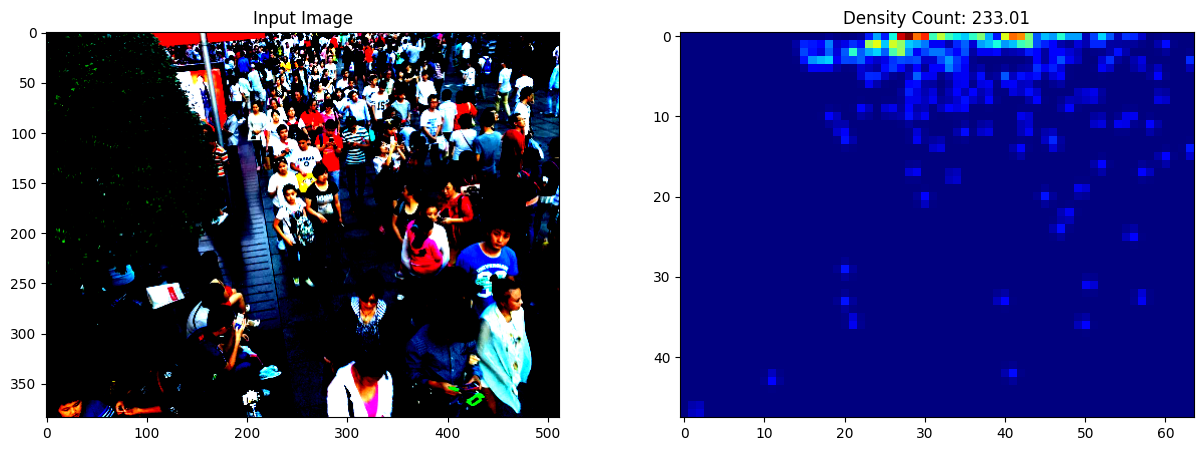

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)

plt.imshow(
    sample_img.permute(1,2,0).numpy()
)

plt.title("Input Image")

plt.subplot(1,2,2)

plt.imshow(
    sample_density.squeeze().numpy(),
    cmap='jet'
)

plt.title(
    f"Density Count: {sample_density.sum().item():.2f}"
)

plt.show()

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

In [ ]:
def make_layers(cfg, in_channels=3, dilation=False):

    layers = []

    d_rate = 2 if dilation else 1

    for v in cfg:

        if v == 'M':

            layers += [
                nn.MaxPool2d(
                    kernel_size=2,
                    stride=2
                )
            ]

        else:

            conv2d = nn.Conv2d(
                in_channels,
                v,
                kernel_size=3,
                padding=d_rate,
                dilation=d_rate
            )

            layers += [
                conv2d,
                nn.ReLU(inplace=True)
            ]

            in_channels = v

    return nn.Sequential(*layers)

In [ ]:
class CSRNet(nn.Module):

    def __init__(self):

        super(CSRNet, self).__init__()

        frontend_feat = [
            64,64,'M',
            128,128,'M',
            256,256,256,'M',
            512,512,512
        ]

        self.frontend = make_layers(frontend_feat)

        vgg16 = models.vgg16(
            weights=models.VGG16_Weights.IMAGENET1K_V1
        )

        self.frontend.load_state_dict(
            vgg16.features[:23].state_dict()
        )

        backend_feat = [
            512,
            512,
            512,
            256,
            128,
            64
        ]

        self.backend = make_layers(
            backend_feat,
            in_channels=512,
            dilation=True
        )

        self.output_layer = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        x = self.frontend(x)

        x = self.backend(x)

        x = self.output_layer(x)

        return x

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = CSRNet().to(DEVICE)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-5
)

print("Using Device:", DEVICE)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 132MB/s]


Using Device: cuda


In [ ]:
EPOCHS = 50

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    loop = tqdm(train_loader)

    for images, density_maps in loop:

        images = images.to(DEVICE)

        density_maps = density_maps.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            density_maps
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        loop.set_description(
            f"Epoch [{epoch+1}/{EPOCHS}]"
        )

        loop.set_postfix(
            loss=loss.item()
        )

    epoch_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1} Average Loss:",
        epoch_loss
    )

    torch.save(
        model.state_dict(),
        f"csrnet_epoch_{epoch+1}.pth"
    )

Epoch [1/50]: 100%|██████████| 200/200 [00:48<00:00,  4.09it/s, loss=0.0054]


Epoch 1 Average Loss: 0.009277208487619646


Epoch [2/50]: 100%|██████████| 200/200 [00:46<00:00,  4.28it/s, loss=0.00762]


Epoch 2 Average Loss: 0.009218481803545729


Epoch [3/50]: 100%|██████████| 200/200 [00:47<00:00,  4.20it/s, loss=0.00498]


...

Epoch 48 Average Loss: 0.0007674128460348584


Epoch [49/50]: 100%|██████████| 200/200 [00:47<00:00,  4.23it/s, loss=0.000172]


Epoch 49 Average Loss: 0.0007508351345313713


Epoch [50/50]: 100%|██████████| 200/200 [00:47<00:00,  4.23it/s, loss=0.00152]


Epoch 50 Average Loss: 0.0004536556309176376


In [ ]:
model.eval()

sample_img, sample_density = test_dataset[0]

with torch.no_grad():

    prediction = model(
        sample_img.unsqueeze(0).to(DEVICE)
    )

pred_density = prediction.squeeze().cpu().numpy()

pred_count = pred_density.sum()

gt_count = sample_density.sum().item()

print("Predicted Count:", pred_count)

print("Ground Truth Count:", gt_count)

Predicted Count: 26.329092
Ground Truth Count: 23.03917121887207


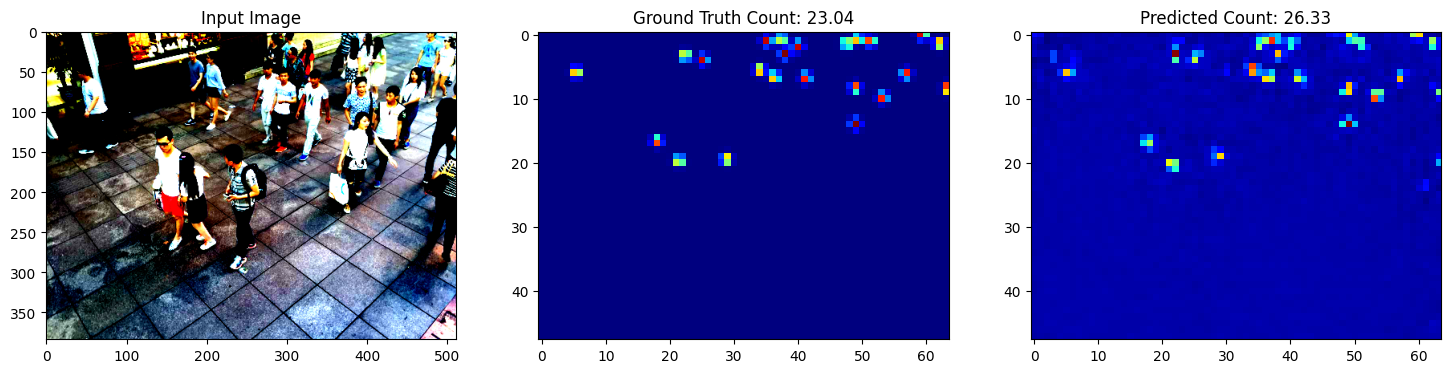

In [ ]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)

plt.imshow(
    sample_img.permute(1,2,0).numpy()
)

plt.title("Input Image")

plt.subplot(1,3,2)

plt.imshow(
    sample_density.squeeze().numpy(),
    cmap='jet'
)

plt.title(
    f"Ground Truth Count: {gt_count:.2f}"
)

plt.subplot(1,3,3)

plt.imshow(
    pred_density,
    cmap='jet'
)

plt.title(
    f"Predicted Count: {pred_count:.2f}"
)

plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "csrnet_final.pth"
)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
from google.colab import files

files.download("csrnet_final.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving IMG_60.jpg to IMG_60.jpg


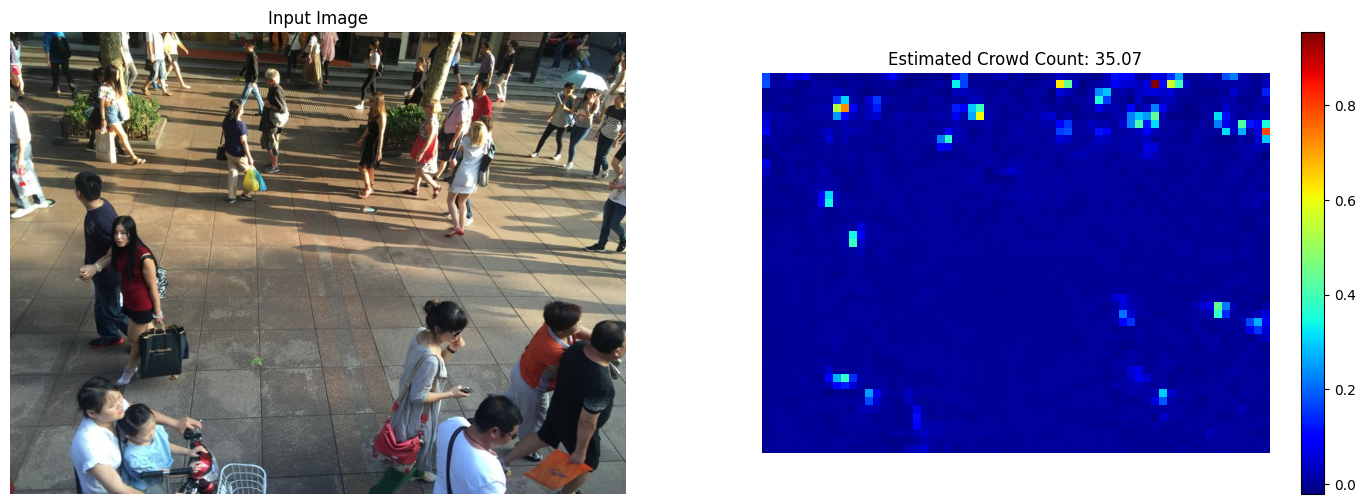

Estimated Crowd Count: 35.07225


In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

# =========================
# UPLOAD IMAGE
# =========================
uploaded = files.upload()

image_name = list(uploaded.keys())[0]

# =========================
# DEVICE
# =========================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# LOAD MODEL
# =========================
model = CSRNet().to(DEVICE)

model.load_state_dict(
    torch.load(
        "csrnet_final.pth",
        map_location=DEVICE
    )
)

model.eval()

# =========================
# READ IMAGE
# =========================
img = cv2.imread(image_name)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

original_img = img.copy()

# =========================
# RESIZE IMAGE
# =========================
img = cv2.resize(
    img,
    (512,384)
)

# =========================
# NORMALIZE IMAGE
# =========================
img = img.astype(np.float32) / 255.0

mean = np.array([0.485, 0.456, 0.406])

std = np.array([0.229, 0.224, 0.225])

img = (img - mean) / std

# =========================
# CONVERT TO TENSOR
# =========================
img_tensor = torch.tensor(img)\
    .permute(2,0,1)\
    .unsqueeze(0)\
    .float()

img_tensor = img_tensor.to(DEVICE)

# =========================
# PREDICTION
# =========================
with torch.no_grad():

    output = model(img_tensor)

density_map = output.squeeze().cpu().numpy()

predicted_count = density_map.sum()

# =========================
# VISUALIZATION
# =========================
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)

plt.imshow(original_img)

plt.title("Input Image")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(density_map, cmap='jet')

plt.title(
    f"Estimated Crowd Count: {predicted_count:.2f}"
)

plt.axis("off")

plt.colorbar()

plt.show()

print("Estimated Crowd Count:", predicted_count)

In [ ]:
import numpy as np

model.eval()

mae = 0
mse = 0

with torch.no_grad():

    for img, gt_density in tqdm(test_loader):

        img = img.to(DEVICE)

        gt_count = gt_density.sum().item()

        pred_density = model(img)

        pred_count = pred_density.sum().item()

        mae += abs(pred_count - gt_count)

        mse += (pred_count - gt_count) ** 2

mae = mae / len(test_loader)

rmse = np.sqrt(mse / len(test_loader))

print(f"MAE  : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

100%|██████████| 316/316 [02:22<00:00,  2.22it/s]

MAE  : 11.68
RMSE : 18.78
